# ROC AUC Speed Benchmark: Unweighted, Weighted (numba vs numpy), and Trapezoidal

This notebook benchmarks the core implementations called by `roc_auc`:

- **Unweighted path** — uses `_roc_auc_mann_whitney` (numba gufunc if available, otherwise `scipy.stats.rankdata`).
- **Weighted path (numba)** — `_roc_auc_mann_whitney_weighted_gufunc`: a numba `@guvectorize` sorted sweep.
- **Weighted path (numpy)** — `_roc_auc_mann_whitney_weighted`: a pure-Python/numpy sorted sweep (the fallback when numba is not installed).
- **Trapezoidal** — `roc` from `scores.plotdata`: computes AUC via the full ROC curve.

All paths are O(n log n), but the constant factor differs significantly. These benchmarks quantify that difference across a range of sample sizes.

## 1. Import Required Libraries

In [ ]:
import timeit

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from scores.plotdata import roc
from scores.probability import roc_auc
from scores.probability.auc_impl import _roc_auc_mann_whitney, _roc_auc_mann_whitney_weighted

try:
    import numba  # noqa

    from scores.probability.auc_numba import _roc_auc_mann_whitney_weighted_gufunc

    HAS_NUMBA = True
    print(f"numba {numba.__version__} detected — benchmarking both numba and numpy paths")
except ImportError:
    HAS_NUMBA = False
    print("numba not installed — only numpy path will be benchmarked")

numba 0.63.1 detected — benchmarking both numba and numpy paths


## 2. Generate Synthetic Forecast and Observation Data

In [2]:
SAMPLE_SIZES = [100, 1_000, 10_000, 100_000]

# Number of timeit repeats per sample size - reduce for large sizes to keep runtime reasonable
REPEATS = {100: 1000, 1_000: 100, 10_000: 20, 100_000: 10}

RNG = np.random.default_rng(42)

SAMPLE_DIM = "__roc_auc_sample__"


def make_data(n: int):
    """Return (fcst, obs, ones) xarray DataArrays of length n."""
    fcst = xr.DataArray(np.round(RNG.random(n), 2), dims=["sample"])
    obs = xr.DataArray(RNG.integers(0, 2, size=n).astype(float), dims=["sample"])
    ones = xr.DataArray(np.ones(n), dims=["sample"])
    return fcst, obs, ones


def roc_auc_weighted_auto(fcst, obs, weights):
    """Call roc_auc with weights through the public API (auto-selects numba/numpy)."""
    return roc_auc(fcst, obs, weights=weights, check_args=False)


def roc_auc_weighted_numpy(fcst, obs, weights):
    """Call the numpy (non-numba) weighted path directly via apply_ufunc."""
    return xr.apply_ufunc(
        _roc_auc_mann_whitney_weighted,
        fcst,
        obs,
        weights,
        input_core_dims=[["sample"], ["sample"], ["sample"]],
        vectorize=True,
        output_dtypes=[float],
    )


if HAS_NUMBA:

    def roc_auc_weighted_numba(fcst, obs, weights):
        """Call the numba gufunc weighted path directly via apply_ufunc."""
        return xr.apply_ufunc(
            _roc_auc_mann_whitney_weighted_gufunc,
            fcst,
            obs,
            weights,
            input_core_dims=[["sample"], ["sample"], ["sample"]],
            output_dtypes=[float],
        )


# Verify all paths produce the same result
fcst_check, obs_check, ones_check = make_data(1000)
auc_uw = float(roc_auc(fcst_check, obs_check, check_args=False))
auc_auto = float(roc_auc_weighted_auto(fcst_check, obs_check, ones_check))
auc_np = float(roc_auc_weighted_numpy(fcst_check, obs_check, ones_check))
auc_roc = float(roc(fcst_check, obs_check, check_args=False)["AUC"])
print(f"Unweighted AUC             : {auc_uw:.6f}")
print(f"Weighted (auto) AUC        : {auc_auto:.6f}")
print(f"Weighted (numpy) AUC       : {auc_np:.6f}")
if HAS_NUMBA:
    auc_nb = float(roc_auc_weighted_numba(fcst_check, obs_check, ones_check))
    print(f"Weighted (numba) AUC       : {auc_nb:.6f}")
print(f"roc (trapezoidal) AUC      : {auc_roc:.6f}")

Unweighted AUC             : 0.509885
Weighted (auto) AUC        : 0.509885
Weighted (numpy) AUC       : 0.509885
Weighted (numba) AUC       : 0.509885
roc (trapezoidal) AUC      : 0.509885


## 3. Benchmark Unweighted `roc_auc`

In [3]:
times_unweighted = {}

for n in SAMPLE_SIZES:
    fcst, obs, _ = make_data(n)
    repeats = REPEATS[n]
    raw = timeit.repeat(
        lambda fcst=fcst, obs=obs: roc_auc(fcst, obs, check_args=False),
        number=1,
        repeat=repeats,
    )
    times_unweighted[n] = np.median(raw)
    print(f"n={n:>9,}  median={times_unweighted[n]*1e3:8.3f} ms  ({repeats} repeats)")

n=      100  median=   2.389 ms  (1000 repeats)
n=    1,000  median=   2.741 ms  (100 repeats)
n=   10,000  median=   4.178 ms  (20 repeats)
n=  100,000  median=  15.356 ms  (10 repeats)


## 4. Benchmark Weighted `roc_auc` — public API (auto-selects backend)

In [4]:
times_weighted_auto = {}

for n in SAMPLE_SIZES:
    fcst, obs, ones = make_data(n)
    repeats = REPEATS[n]
    raw = timeit.repeat(
        lambda fcst=fcst, obs=obs, ones=ones: roc_auc_weighted_auto(fcst, obs, ones),
        number=1,
        repeat=repeats,
    )
    times_weighted_auto[n] = np.median(raw)
    print(f"n={n:>9,}  median={times_weighted_auto[n]*1e3:8.3f} ms  ({repeats} repeats)")

n=      100  median=   4.455 ms  (1000 repeats)
n=    1,000  median=   4.595 ms  (100 repeats)
n=   10,000  median=   5.979 ms  (20 repeats)
n=  100,000  median=  21.354 ms  (10 repeats)


## 5. Benchmark Weighted `roc_auc` — numba gufunc

In [5]:
times_weighted_numba = {}

if HAS_NUMBA:
    for n in SAMPLE_SIZES:
        fcst, obs, ones = make_data(n)
        repeats = REPEATS[n]
        raw = timeit.repeat(
            lambda fcst=fcst, obs=obs, ones=ones: roc_auc_weighted_numba(fcst, obs, ones),
            number=1,
            repeat=repeats,
        )
        times_weighted_numba[n] = np.median(raw)
        print(f"n={n:>9,}  median={times_weighted_numba[n]*1e3:8.3f} ms  ({repeats} repeats)")
else:
    print("Skipped — numba not installed")

n=      100  median=   0.145 ms  (1000 repeats)
n=    1,000  median=   0.192 ms  (100 repeats)
n=   10,000  median=   0.926 ms  (20 repeats)
n=  100,000  median=   9.421 ms  (10 repeats)


## 6. Benchmark Weighted `roc_auc` — numpy fallback

In [6]:
times_weighted_numpy = {}

for n in SAMPLE_SIZES:
    fcst, obs, ones = make_data(n)
    repeats = REPEATS[n]
    raw = timeit.repeat(
        lambda fcst=fcst, obs=obs, ones=ones: roc_auc_weighted_numpy(fcst, obs, ones),
        number=1,
        repeat=repeats,
    )
    times_weighted_numpy[n] = np.median(raw)
    print(f"n={n:>9,}  median={times_weighted_numpy[n]*1e3:8.3f} ms  ({repeats} repeats)")

n=      100  median=   1.129 ms  (1000 repeats)
n=    1,000  median=   1.918 ms  (100 repeats)
n=   10,000  median=   5.142 ms  (20 repeats)
n=  100,000  median=  34.774 ms  (10 repeats)


## 7. Benchmark `roc` (Trapezoidal AUC)

In [7]:
times_roc = {}

for n in SAMPLE_SIZES:
    fcst, obs, _ = make_data(n)
    repeats = REPEATS[n]
    raw = timeit.repeat(
        lambda fcst=fcst, obs=obs: roc(fcst, obs, check_args=False),
        number=1,
        repeat=repeats,
    )
    times_roc[n] = np.median(raw)
    print(f"n={n:>9,}  median={times_roc[n]*1e3:8.3f} ms  ({repeats} repeats)")

n=      100  median=  13.167 ms  (1000 repeats)
n=    1,000  median=  16.742 ms  (100 repeats)
n=   10,000  median=  69.931 ms  (20 repeats)
n=  100,000  median= 575.026 ms  (10 repeats)


## 8. Compare Results Across Sample Sizes

In [8]:
data = {
    "unweighted_ms": {n: t * 1e3 for n, t in times_unweighted.items()},
    "weighted_auto_ms": {n: t * 1e3 for n, t in times_weighted_auto.items()},
    "weighted_numpy_ms": {n: t * 1e3 for n, t in times_weighted_numpy.items()},
    "roc_ms": {n: t * 1e3 for n, t in times_roc.items()},
}
if times_weighted_numba:
    data["weighted_numba_ms"] = {n: t * 1e3 for n, t in times_weighted_numba.items()}

df = pd.DataFrame(data)
df.index.name = "sample_size"

# Reorder columns so numba comes right after auto
cols = ["unweighted_ms", "weighted_auto_ms"]
if "weighted_numba_ms" in df.columns:
    cols.append("weighted_numba_ms")
cols += ["weighted_numpy_ms", "roc_ms"]
df = df[cols]

# Ratios
if "weighted_numba_ms" in df.columns:
    df["numba/unweighted"] = df["weighted_numba_ms"] / df["unweighted_ms"]
df["numpy/unweighted"] = df["weighted_numpy_ms"] / df["unweighted_ms"]
if "weighted_numba_ms" in df.columns:
    df["numpy/numba"] = df["weighted_numpy_ms"] / df["weighted_numba_ms"]
df["roc/unweighted"] = df["roc_ms"] / df["unweighted_ms"]

pd.set_option("display.float_format", "{:.3f}".format)
print(df.to_string())

             unweighted_ms  weighted_auto_ms  weighted_numba_ms  weighted_numpy_ms  roc_ms  numba/unweighted  numpy/unweighted  numpy/numba  roc/unweighted
sample_size                                                                                                                                                
100                  2.389             4.455              0.145              1.129  13.167             0.061             0.472        7.776           5.511
1000                 2.741             4.595              0.192              1.918  16.742             0.070             0.700       10.007           6.107
10000                4.178             5.979              0.926              5.142  69.931             0.222             1.231        5.555          16.739
100000              15.356            21.354              9.421             34.774 575.026             0.614             2.264        3.691          37.446


## 9. Visualise Benchmark Results

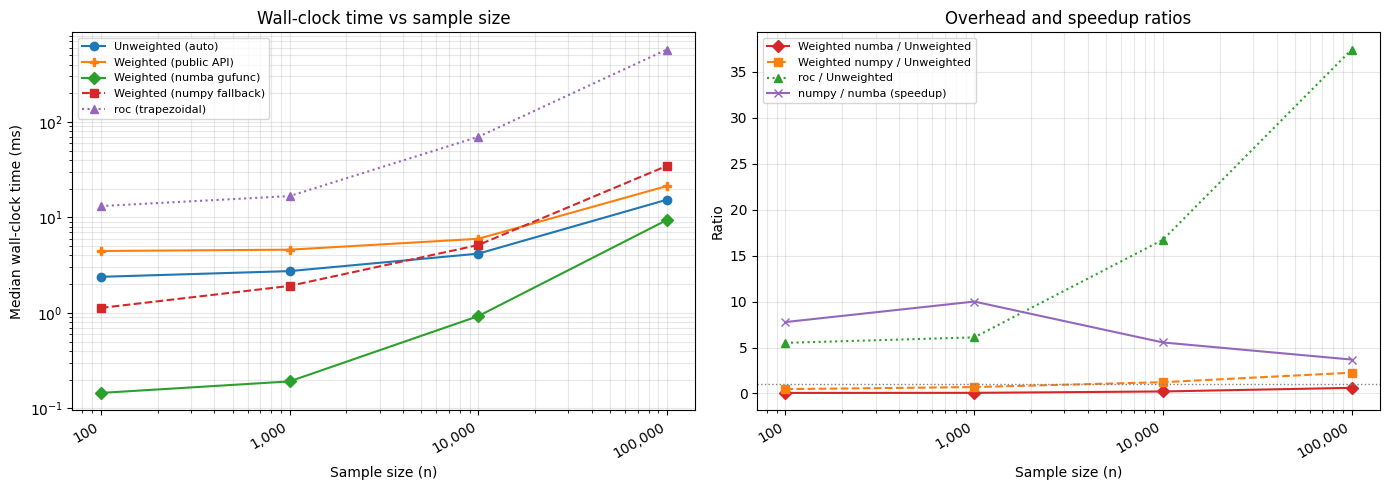

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ns = df.index.values

# ── Left: wall-clock time (log-log) ──────────────────────────────────────────
ax1.loglog(ns, df["unweighted_ms"], "o-", label="Unweighted (auto)")
ax1.loglog(ns, df["weighted_auto_ms"], "P-", label="Weighted (public API)")
if "weighted_numba_ms" in df.columns:
    ax1.loglog(ns, df["weighted_numba_ms"], "D-", label="Weighted (numba gufunc)")
ax1.loglog(ns, df["weighted_numpy_ms"], "s--", label="Weighted (numpy fallback)")
ax1.loglog(ns, df["roc_ms"], "^:", label="roc (trapezoidal)")
ax1.set_xlabel("Sample size (n)")
ax1.set_ylabel("Median wall-clock time (ms)")
ax1.set_title("Wall-clock time vs sample size")
ax1.legend(fontsize=8)
ax1.grid(True, which="both", alpha=0.3)
ax1.set_xticks(ns)
ax1.set_xticklabels([f"{n:,}" for n in ns], rotation=30, ha="right")

# ── Right: overhead ratio relative to unweighted ─────────────────────────────
if "numba/unweighted" in df.columns:
    ax2.semilogx(ns, df["numba/unweighted"], "D-", label="Weighted numba / Unweighted", color="tab:red")
ax2.semilogx(ns, df["numpy/unweighted"], "s--", label="Weighted numpy / Unweighted", color="tab:orange")
ax2.semilogx(ns, df["roc/unweighted"], "^:", label="roc / Unweighted", color="tab:green")
if "numpy/numba" in df.columns:
    ax2.semilogx(ns, df["numpy/numba"], "x-", label="numpy / numba (speedup)", color="tab:purple")
ax2.axhline(1.0, color="grey", linestyle=":", linewidth=1)
ax2.set_xlabel("Sample size (n)")
ax2.set_ylabel("Ratio")
ax2.set_title("Overhead and speedup ratios")
ax2.legend(fontsize=8)
ax2.grid(True, which="both", alpha=0.3)
ax2.set_xticks(ns)
ax2.set_xticklabels([f"{n:,}" for n in ns], rotation=30, ha="right")

fig.tight_layout()
plt.show()